# B+ Tree based Lightweight DBMS

**Course**: CS432 - Databases (IIT Gandhinagar)  
**Assignment**: 2, Module A  
**Instructor**: Dr. Yogesh K. Meena  

---

## Introduction

### What are we doing here?

So the basic problem is... how do you store and retrieve data quickly? A simple list works fine when you have like 10 records, but when it goes to 10,000 or 100,000 things just get really slow. That's where B+ Trees come in.

In this module we built a **B+ Tree** from scratch (no external libraries!) and used it as the indexing engine for a lightweight DBMS. Then we compared it against a basic brute force approach to actually see the difference in performance.

### Why B+ Tree specifically?

Honestly we could have used a hash map or something, but B+ Trees are the standard in real databases (Postgres, MySQL all use them internally) because:
- insert, delete, search all take O(log n) time which is really good
- the leaf nodes are linked together so range queries are super fast
- the tree stays balanced always, so worst case performance is predictable

### What we built

| Thing | What it does |
|-------|-----------|
| `BPlusTree` | the main tree with all operations |
| `BruteForceDB` | a simple list we compare against |
| `Table` | wraps the tree to look like a DB table |
| `DatabaseManager` | manages multiple tables at once |
| `PerformanceAnalyzer` | runs all the benchmarks |

---

In [14]:
# basic imports, nothing fancy
import sys, os, time, random, math
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import Image, display

# add current folder to path so python can find our database package
sys.path.insert(0, os.path.abspath('.'))

from database.bplustree  import BPlusTree
from database.bruteforce import BruteForceDB
from database.table      import Table
from database.db_manager import DatabaseManager

# dark theme for all plots, looks cleaner imo
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 12,
    'axes.facecolor'  : '#1a1a2e',
    'figure.facecolor': '#0f0f1e',
    'axes.edgecolor'  : '#333366',
    'axes.labelcolor' : '#e0e0ff',
    'xtick.color'     : '#9999cc',
    'ytick.color'     : '#9999cc',
    'text.color'      : '#e0e0ff',
    'grid.color'      : '#222244',
    'grid.alpha'      : 0.4,
    'lines.linewidth' : 2,
})

# colors for the charts
BPTREE_COLOR = '#6366f1'
BRUTE_COLOR  = '#ef4444'
ACCENT_COLOR = '#22c55e'

print('imports ok :)')

imports ok :)


---

## Implementation Details

### How the B+ Tree works

Quick breakdown of the properties we used (order = 4):

| Property | Value |
|----------|---------|
| Order (max children per node) | 4 |
| Max keys per node | 3 |
| Min keys per non-root node | 1 |
| Where data lives | leaf nodes only |
| Leaf connection | singly linked list |
| Insert time | O(log n) |
| Search time | O(log n) |
| Delete time | O(log n) |
| Range query | O(log n + k) |

### A few things that tripped us up initially...

1. **Leaf split vs internal split** - when you split a leaf, the middle key gets *copied* up to the parent (it still stays in the leaf). But when you split an internal node, the middle key gets *moved* up (removed from the child). Easy to mess this up.

2. **Linked list maintenance** - every time you split or merge leaf nodes you have to carefully update the `.next` pointers. Miss one and range queries break silently which is annoying to debug.

3. **Delete underflow** - when a node has too few keys after deletion, you first try to borrow from a sibling, and only merge if no sibling has extra keys. The order matters.

In [15]:
# let's actually test out the tree with some sample data
print('=== basic B+ Tree demo (order=4) ===')

tree = BPlusTree(order=4)

# inserting some records with random-ish keys
sample_records = [
    (10, 'Dr. Rajesh Kumar'),
    (5,  'Arjun Mehta'),
    (20, 'Priya Sharma'),
    (15, 'Kavya Nair'),
    (25, 'Ramesh Gupta'),
    (3,  'Sunita Patel'),
    (8,  'Vivek Joshi'),
    (30, 'Anita Bose'),
    (12, 'Deepak Singh'),
    (18, 'Meena Reddy'),
]

for key, name in sample_records:
    tree.insert(key, {'id': key, 'name': name})

print(f'total records inserted: {len(tree)}')

# exact search test
result = tree.search(10)
print(f'search(10) -> {result}')
print(f'search(99) -> {tree.search(99)}  (not in tree, should be None)')

# range query... this is where the linked list helps a lot
rng = tree.range_query(8, 20)
print(f'range(8, 20) -> {[v["name"] for _, v in rng]}')

# update an existing key
tree.update(10, {'id': 10, 'name': 'Dr. Rajesh Kumar (updated)'})
print(f'after update(10) -> {tree.search(10)}')

# delete and verify
print(f'delete(15) -> {tree.delete(15)}')
print(f'keys after delete -> {[v["name"] for _, v in tree.get_all()]}')

# contains check
print(f'15 in tree -> {15 in tree}  (deleted, should be False)')
print(f'18 in tree -> {18 in tree}  (exists, should be True)')

=== basic B+ Tree demo (order=4) ===
total records inserted: 10
search(10) -> {'id': 10, 'name': 'Dr. Rajesh Kumar'}
search(99) -> None  (not in tree, should be None)
range(8, 20) -> ['Vivek Joshi', 'Dr. Rajesh Kumar', 'Deepak Singh', 'Kavya Nair', 'Meena Reddy', 'Priya Sharma']
after update(10) -> {'id': 10, 'name': 'Dr. Rajesh Kumar (updated)'}
delete(15) -> True
keys after delete -> ['Sunita Patel', 'Arjun Mehta', 'Vivek Joshi', 'Dr. Rajesh Kumar (updated)', 'Deepak Singh', 'Meena Reddy', 'Priya Sharma', 'Ramesh Gupta', 'Anita Bose']
15 in tree -> False  (deleted, should be False)
18 in tree -> True  (exists, should be True)


In [16]:
# quick demo of the DatabaseManager with GateGuard tables
print('=== DatabaseManager demo ===')

# this creates all 10 GateGuard tables from assignment 1 schema
db = DatabaseManager.create_gateguard_db(order=4)
members = db['Member']

# add a few sample members
member_data = [
    {'MemberID': 1, 'Name': 'Dr. Rajesh Kumar',   'Email': 'rajesh@iitgn.ac.in',    'TypeID': 1, 'Department': 'CS'},
    {'MemberID': 2, 'Name': 'Arjun Mehta',        'Email': 'arjun.m@iitgn.ac.in',   'TypeID': 2, 'Department': 'Electrical'},
    {'MemberID': 3, 'Name': 'Priya Sharma',       'Email': 'priya.s@iitgn.ac.in',   'TypeID': 2, 'Department': 'Mathematics'},
    {'MemberID': 4, 'Name': 'Ramesh Kumar',       'Email': 'ramesh22@gmail.com',     'TypeID': 3, 'Department': None},
    {'MemberID': 5, 'Name': 'Kavya Nair',         'Email': 'kavya.n@iitgn.ac.in',   'TypeID': 2, 'Department': 'Physics'},
]

for m in member_data:
    members.insert(m)

print(f'member count: {members.count()}')
print(f'select(2): {members.select(2)}')

# filter by type (TypeID = 2 means student)
students = members.filter(lambda r: r.get('TypeID') == 2)
print(f'students (TypeID=2): {[s["Name"] for s in students]}')

db.stats()

=== DatabaseManager demo ===
[DB] Created table 'MemberType' (pk='TypeID', order=4)
[DB] Created table 'Member' (pk='MemberID', order=4)
[DB] Created table 'VehicleType' (pk='TypeID', order=4)
[DB] Created table 'Vehicle' (pk='VehicleID', order=4)
[DB] Created table 'Gate' (pk='GateID', order=4)
[DB] Created table 'GateOccupancy' (pk='OccupancyID', order=4)
[DB] Created table 'Role' (pk='RoleID', order=4)
[DB] Created table 'User' (pk='UserID', order=4)
[DB] Created table 'PersonVisit' (pk='VisitID', order=4)
[DB] Created table 'VehicleVisit' (pk='VVVisitID', order=4)
member count: 5
select(2): {'MemberID': 2, 'Name': 'Arjun Mehta', 'Email': 'arjun.m@iitgn.ac.in', 'TypeID': 2, 'Department': 'Electrical'}
students (TypeID=2): ['Arjun Mehta', 'Priya Sharma', 'Kavya Nair']

  Database : GateGuardDB
  Tables   : 10
  Table Name                   Records  PK             
  --------------------------------------------------
  MemberType                         0  TypeID         
  Member    

---

## Visualisation - what the tree actually looks like

One of the assignment requirements is to visualise the tree structure using Graphviz. So we added a `visualize_tree()` method that generates a nice dark themed graph showing:
- internal nodes in dark blue/indigo (just routing keys)
- leaf nodes in dark green (actual data lives here)
- solid arrows for parent to child connections
- dashed green arrows for the leaf linked list

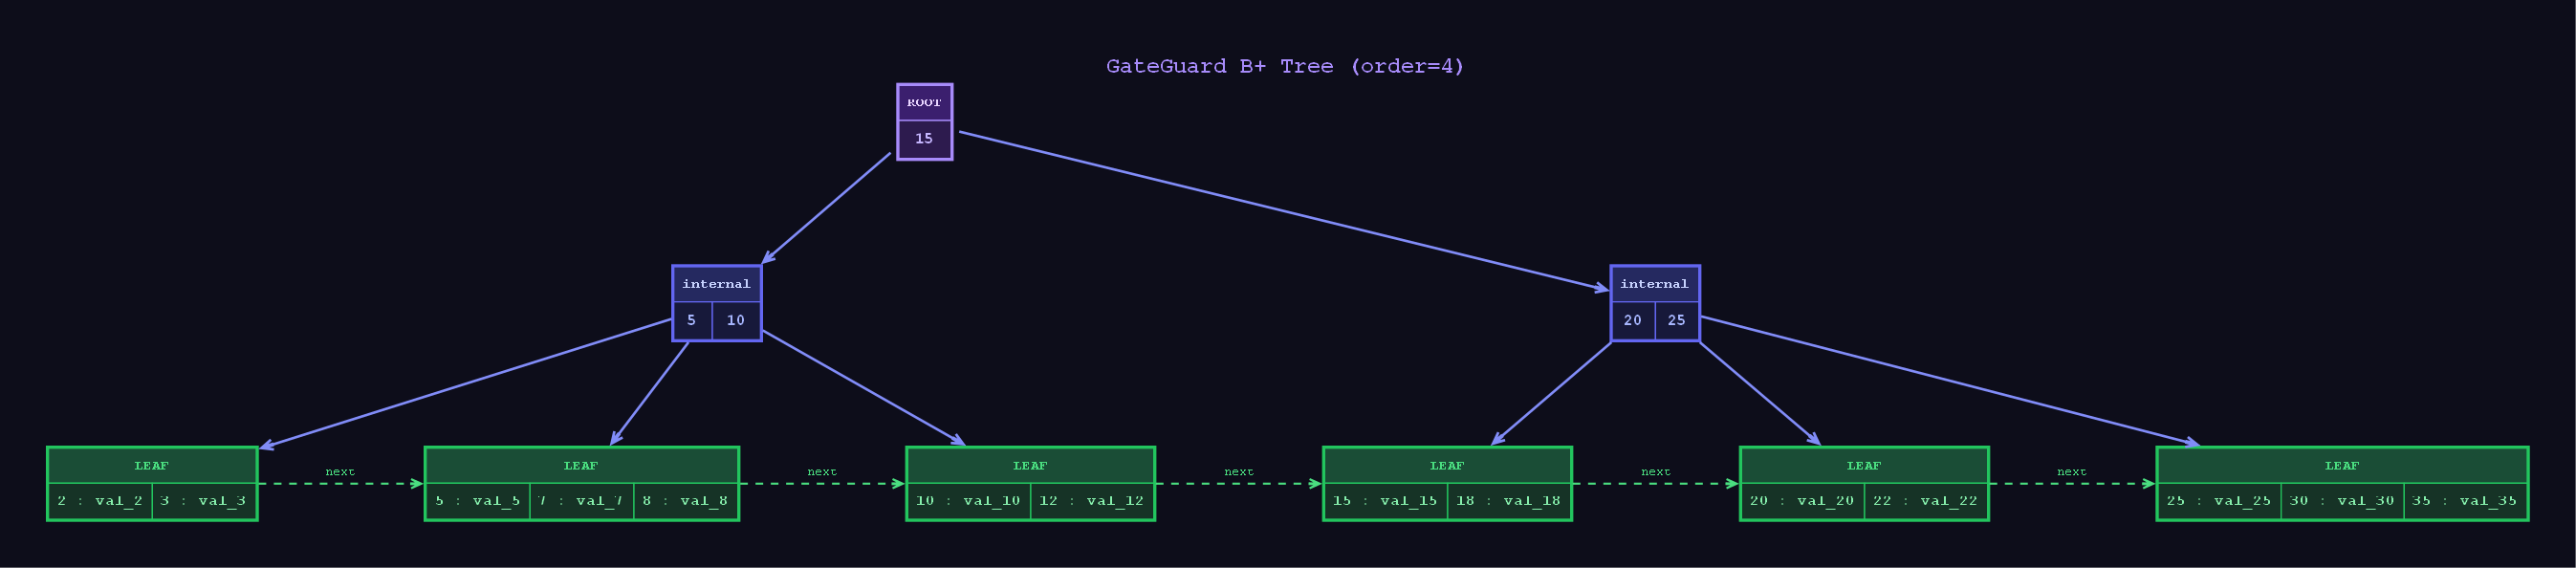

tree visualization saved as tree_visualization.png


In [17]:
# build a small tree just for visualization purposes
# using more keys so we can see splits and multiple levels
viz_tree = BPlusTree(order=4)
for k in [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]:
    viz_tree.insert(k, f'val_{k}')

try:
    dot = viz_tree.visualize_tree(title='GateGuard B+ Tree (order=4)')
    dot.render('tree_visualization', format='png', cleanup=True)
    display(Image('tree_visualization.png'))
    print('tree visualization saved as tree_visualization.png')
except Exception as e:
    # graphviz might not be installed, just print keys in that case
    print(f'graphviz not available: {e}')
    print('keys in order:', [k for k, _ in viz_tree.get_all()])

Tree visualization saved to member_table_tree.png


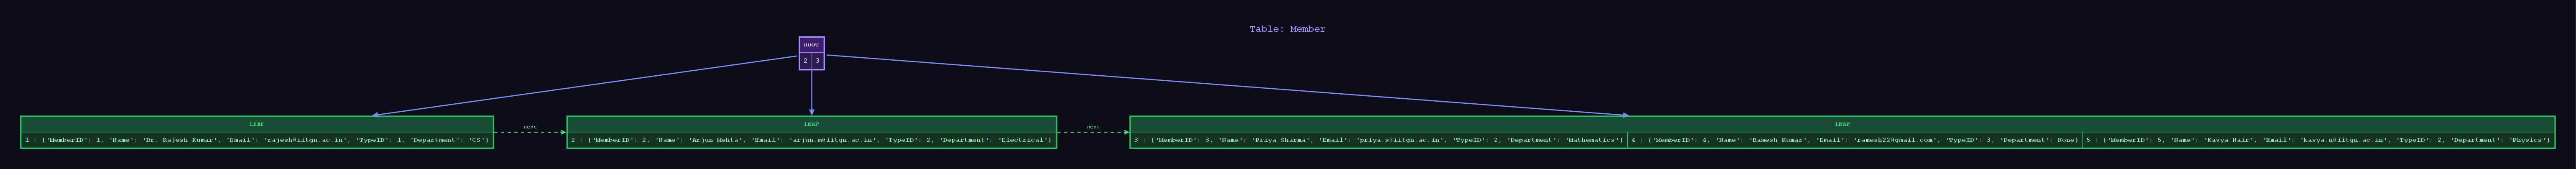

In [18]:
# also visualizing the member table btree specifically
members_viz = Table('Member', ['MemberID', 'Name', 'Email', 'TypeID'], 'MemberID', order=4)
for m in member_data:
    members_viz.insert(m)

try:
    dot2 = members_viz.visualize('member_table_tree', fmt='png')
    display(Image('member_table_tree.png'))
except Exception as e:
    print(f'graphviz not available: {e}')

---

## Step-by-Step Insertion Trace

Here I am not showing only the final tree.  
I am also showing how the tree changes during insertion, so it is easy to understand where splits happen.

I used the same 14-key input sequence and captured 5 important checkpoints:

| Snapshot | Keys inserted so far | What happened |
|----------|----------------------|---------------|
| Step 3   | 10, 20, 5            | Root is still one leaf node. No split yet (3 keys is full for order 4 leaf). |
| Step 4   | + 15                 | First overflow happens. Leaf splits, and one key is copied up to parent. Tree becomes 2 levels. |
| Step 7   | + 25, 3, 7           | More leaf splits happen. Internal node now stores more routing keys. |
| Step 10  | + 12, 18, 30         | Internal node overflows and splits. Middle key is promoted up. Tree becomes 3 levels. |
| Step 14  | + 35, 2, 8, 22       | Final tree after all inserts. Total 14 keys, 6 leaf nodes, and leaf links are correct. |

The most important checkpoints are:
- **Step 4**: leaf split (copy-up)
- **Step 10**: internal split (promote-up)

These two steps show the two different split behaviors used in my implementation.

=== Step-by-step insertion trace :) (order=4) ===
Sequence: [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]

-----------------------------------------------------------------
STEP  3 | After inserting 10, 20, 5
NOTE   | Root is still a single leaf node (3 keys = max 3). No split yet.
KEYS   | [5, 10, 20]  (total: 3)


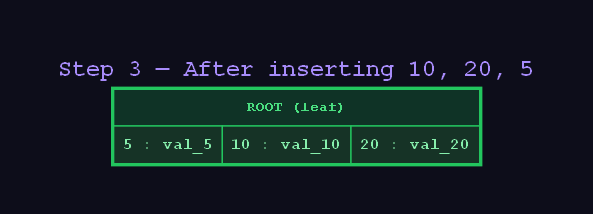


-----------------------------------------------------------------
STEP  4 | After inserting +15  -->  FIRST SPLIT (leaf copy-up)
NOTE   | Leaf overflows with 4 keys. Copy-up split: key 10 pushed up to new root. Tree now has 2 levels.
KEYS   | [5, 10, 15, 20]  (total: 4)


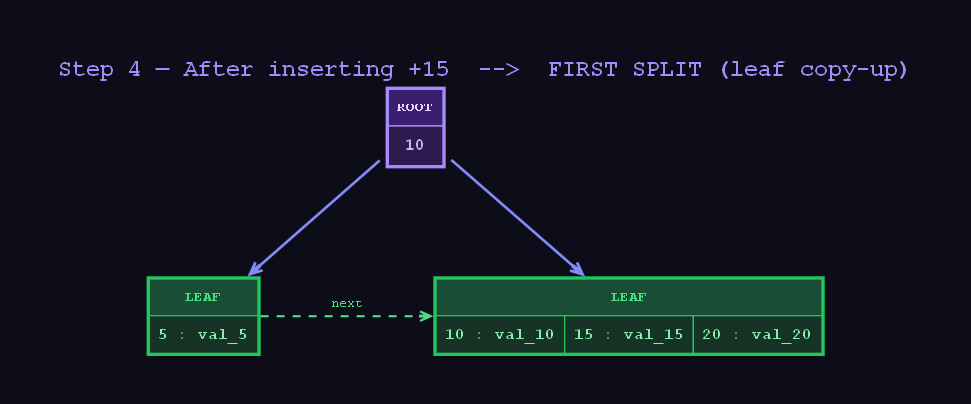


-----------------------------------------------------------------
STEP  7 | After inserting +25, 3, 7  -->  more leaf splits
NOTE   | Two more leaf splits. Internal node has 2 routing keys. Still 2 levels.
KEYS   | [3, 5, 7, 10, 15, 20, 25]  (total: 7)


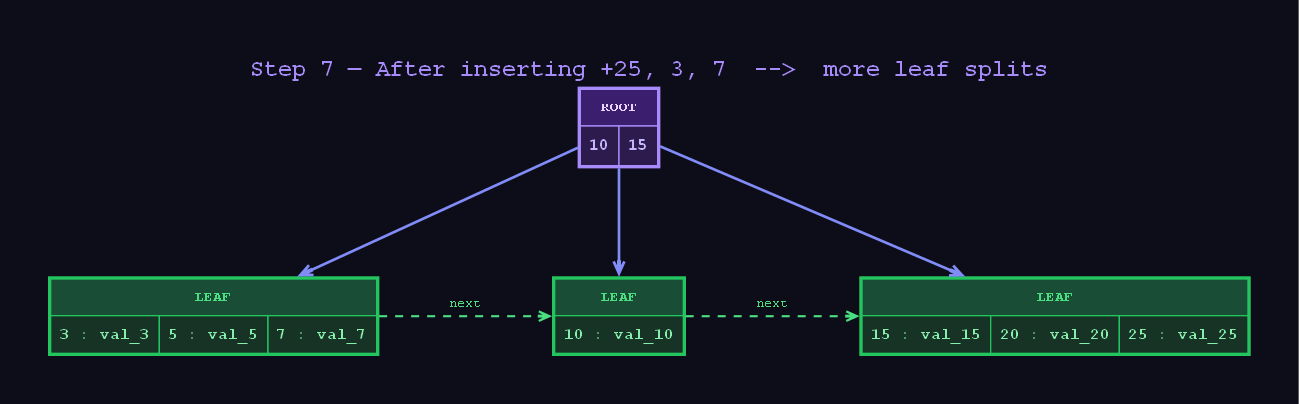


-----------------------------------------------------------------
STEP 10 | After inserting +12, 18, 30  -->  INTERNAL SPLIT (promote-up, tree grows taller)
NOTE   | Internal node overflows. Promote-up split: middle key moves up to create new root. Now 3 levels!
KEYS   | [3, 5, 7, 10, 12, 15, 18, 20, 25, 30]  (total: 10)


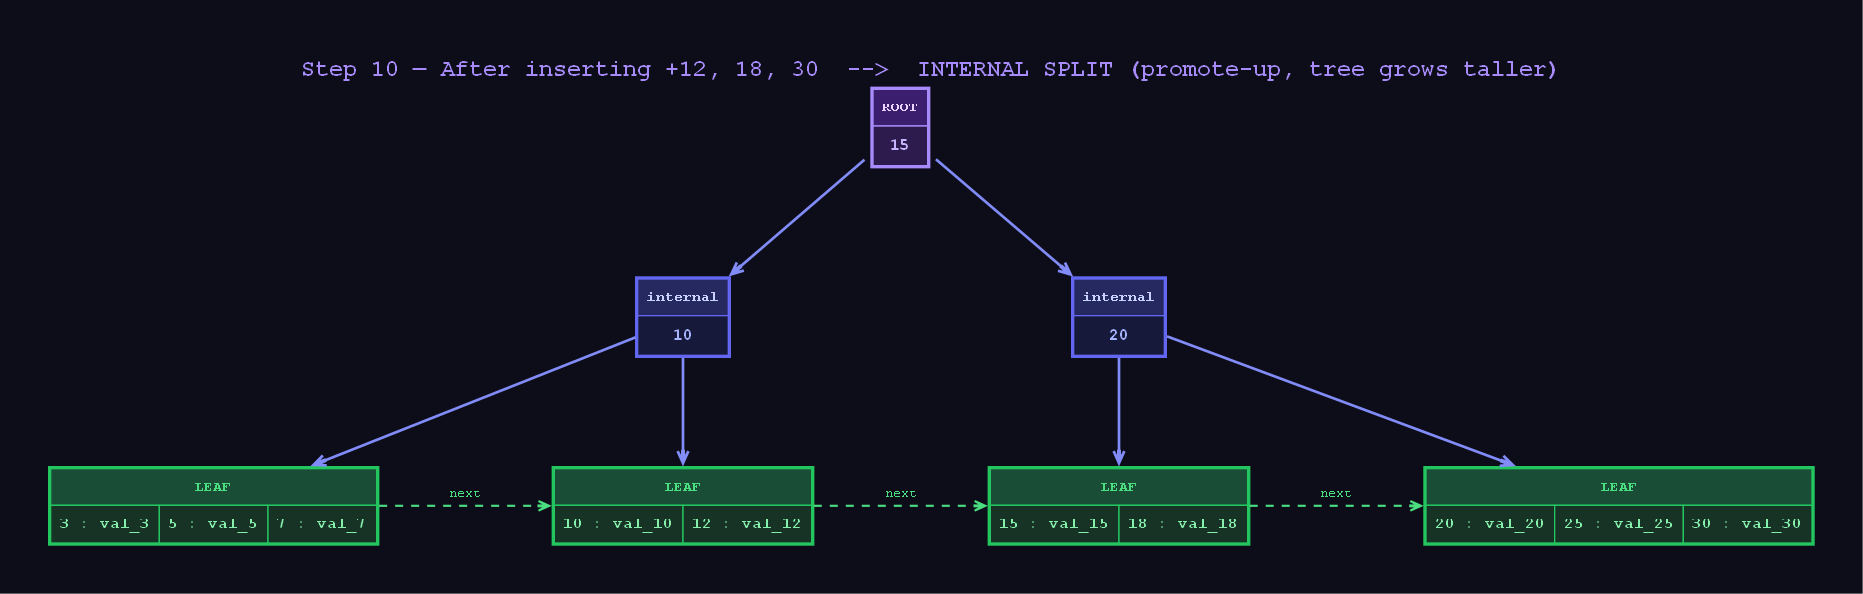


-----------------------------------------------------------------
STEP 14 | After inserting +35, 2, 8, 22  -->  FINAL TREE
NOTE   | All 14 keys inserted. 6 leaf nodes connected by linked list. Full 3-level B+ Tree.
KEYS   | [2, 3, 5, 7, 8, 10, 12, 15, 18, 20, 22, 25, 30, 35]  (total: 14)


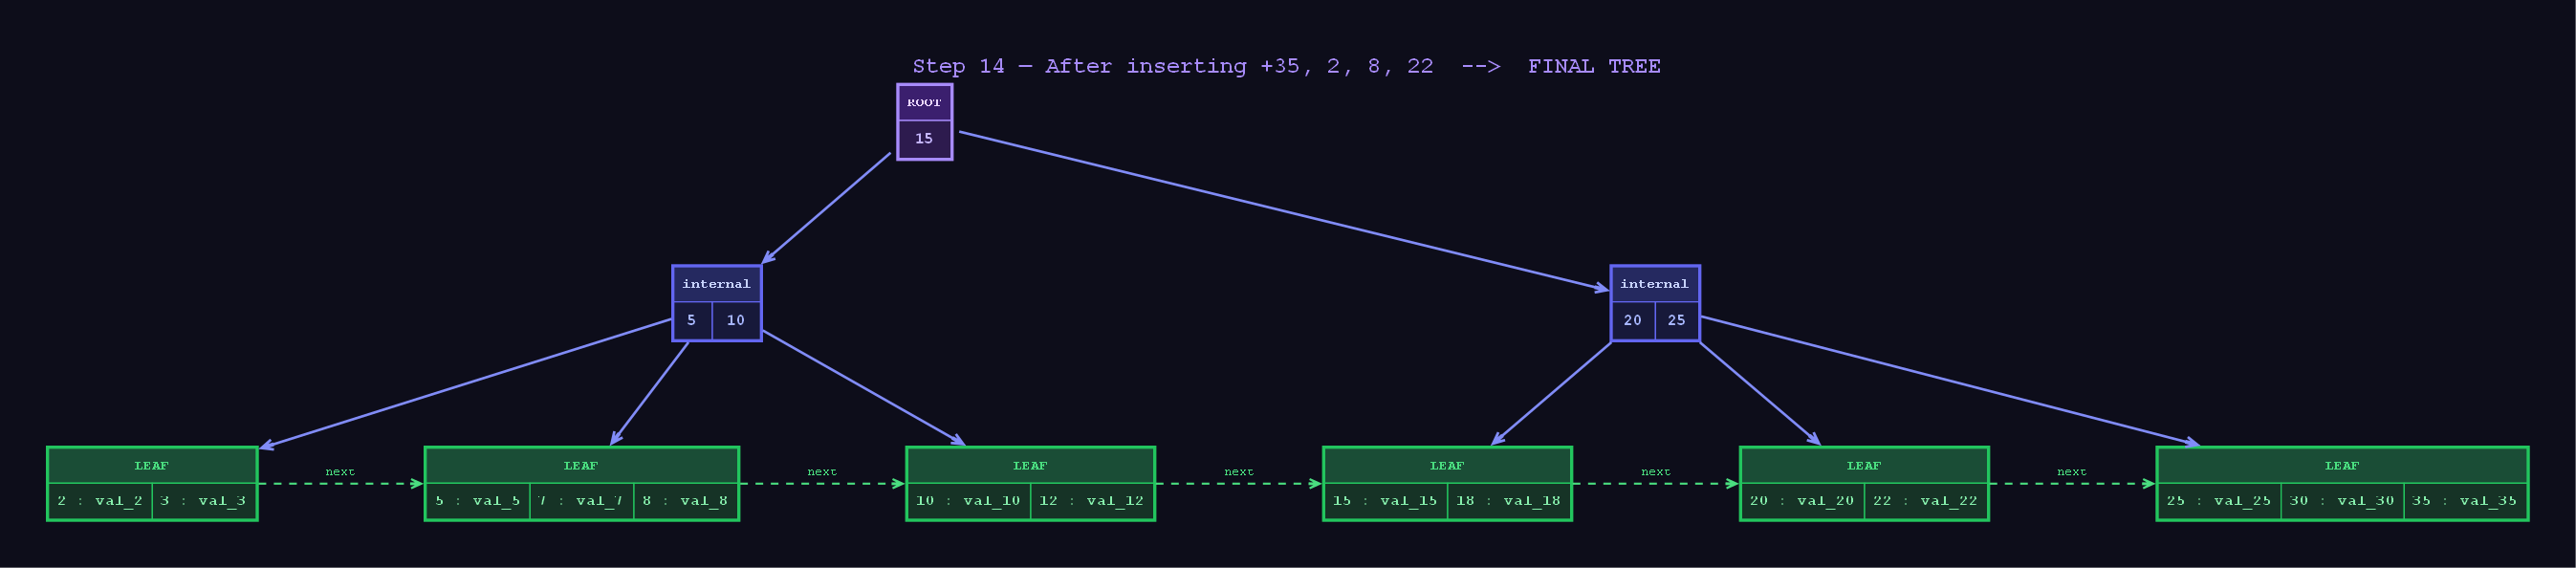


-----------------------------------------------------------------
Done. 5 step snapshots saved:
  step_03_tree.png
  step_04_tree.png
  step_07_tree.png
  step_10_tree.png
  step_14_tree.png


In [19]:
# Step-by-step insertion visualization
# Captures 5 snapshots of the tree during insertion of the 14-key sequence
# showing both leaf copy-up splits and internal promote-up splits in action

print('=== Step-by-step insertion trace :) (order=4) ===')
print('Sequence: [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]')
print()

step_sequence = [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]

# checkpoints: step -> (short title, explanation note)
checkpoints = {
    3: (
        'After inserting 10, 20, 5',
        'Root is still a single leaf node (3 keys = max 3). No split yet.'
    ),
    4: (
        'After inserting +15  -->  FIRST SPLIT (leaf copy-up)',
        'Leaf overflows with 4 keys. Copy-up split: key 10 pushed up to new root. Tree now has 2 levels.'
    ),
    7: (
        'After inserting +25, 3, 7  -->  more leaf splits',
        'Two more leaf splits. Internal node has 2 routing keys. Still 2 levels.'
    ),
    10: (
        'After inserting +12, 18, 30  -->  INTERNAL SPLIT (promote-up, tree grows taller)',
        'Internal node overflows. Promote-up split: middle key moves up to create new root. Now 3 levels!'
    ),
    14: (
        'After inserting +35, 2, 8, 22  -->  FINAL TREE',
        'All 14 keys inserted. 6 leaf nodes connected by linked list. Full 3-level B+ Tree.'
    ),
}

step_tree = BPlusTree(order=4)
saved_files = []

for i, k in enumerate(step_sequence, 1):
    step_tree.insert(k, f'val_{k}')

    if i not in checkpoints:
        continue

    title_short, note = checkpoints[i]
    filename = f'step_{i:02d}_tree'
    keys_so_far = [key for key, _ in step_tree.get_all()]

    print('-' * 65)
    print(f'STEP {i:2d} | {title_short}')
    print(f'NOTE   | {note}')
    print(f'KEYS   | {keys_so_far}  (total: {len(step_tree)})')

    try:
        dot = step_tree.visualize_tree(title=f'Step {i} — {title_short}')
        dot.render(filename, format='png', cleanup=True)
        display(Image(f'{filename}.png'))
        saved_files.append(f'{filename}.png')
    except Exception as e:
        print(f'SKIP   | graphviz not available: {e}')
    print()

print('-' * 65)
if saved_files:
    print(f'Done. {len(saved_files)} step snapshots saved:')
    for sf in saved_files:
        print(f'  {sf}')
else:
    print('Done. (no PNG files saved... graphviz not available)')


---

## Performance Analysis

Ok so this is the main experiment part. We compared B+ Tree vs BruteForceDB across 6 different metrics. BruteForceDB is literally just a Python list with linear scans, so it's our baseline.

We ran the tests across dataset sizes from 100 to 100,000 keys (step of 1000), which gives a nice picture of how performance scales.

The 6 things we measured:
1. Insertion time
2. Search time
3. Deletion time
4. Range query time
5. Mixed random operations
6. Memory usage

In [6]:
# benchmarking class (optimized for stability + runtime control)
class PerformanceAnalyzer:
    
    def __init__(self, order=4):
        self.order = order
        self.results = {}
        self._data_sizes = []

    def _make_keys(self, n):
        # generate n unique random keys
        return random.sample(range(1, n * 10), n)

    def _bench_insert(self, sizes):
        bt_times, bf_times = [], []
        for n in sizes:
            keys = self._make_keys(n)

            tree = BPlusTree(order=self.order)
            t0 = time.perf_counter()
            for k in keys:
                tree.insert(k, k)
            bt_times.append(time.perf_counter() - t0)

            brute = BruteForceDB()
            t0 = time.perf_counter()
            for k in keys:
                brute.insert(k, k)
            bf_times.append(time.perf_counter() - t0)

        return bt_times, bf_times

    def _bench_search(self, sizes, query_count=120):
        bt_times, bf_times = [], []
        for n in sizes:
            keys = self._make_keys(n)
            search_keys = random.sample(keys, min(query_count, n))

            tree = BPlusTree(order=self.order)
            for k in keys:
                tree.insert(k, k)
            t0 = time.perf_counter()
            for k in search_keys:
                tree.search(k)
            bt_times.append(time.perf_counter() - t0)

            brute = BruteForceDB()
            for k in keys:
                brute.insert(k, k)
            t0 = time.perf_counter()
            for k in search_keys:
                brute.search(k)
            bf_times.append(time.perf_counter() - t0)

        return bt_times, bf_times

    def _bench_delete(self, sizes, delete_count=120):
        bt_times, bf_times = [], []
        for n in sizes:
            keys = self._make_keys(n)
            del_keys = random.sample(keys, min(delete_count, n))

            tree = BPlusTree(order=self.order)
            for k in keys:
                tree.insert(k, k)
            t0 = time.perf_counter()
            for k in del_keys:
                tree.delete(k)
            bt_times.append(time.perf_counter() - t0)

            brute = BruteForceDB()
            for k in keys:
                brute.insert(k, k)
            t0 = time.perf_counter()
            for k in del_keys:
                brute.delete(k)
            bf_times.append(time.perf_counter() - t0)

        return bt_times, bf_times

    def _bench_range(self, sizes, range_size=100, range_queries=30):
        bt_times, bf_times = [], []
        for n in sizes:
            keys = self._make_keys(n)
            max_key = max(keys)

            tree = BPlusTree(order=self.order)
            for k in keys:
                tree.insert(k, k)
            t0 = time.perf_counter()
            for _ in range(range_queries):
                s = random.randint(1, max(1, max_key - range_size))
                tree.range_query(s, s + range_size)
            bt_times.append(time.perf_counter() - t0)

            brute = BruteForceDB()
            for k in keys:
                brute.insert(k, k)
            t0 = time.perf_counter()
            for _ in range(range_queries):
                s = random.randint(1, max(1, max_key - range_size))
                brute.range_query(s, s + range_size)
            bf_times.append(time.perf_counter() - t0)

        return bt_times, bf_times

    def _bench_random(self, sizes, ops_per_size=80):
        """
        Mixed workload benchmark.
        Uses deletes only on currently existing keys to avoid pathological miss-heavy delete runs.
        """
        bt_times, bf_times = [], []

        for n in sizes:
            keys = self._make_keys(n)

            # B+ tree setup
            tree = BPlusTree(order=self.order)
            for k in keys:
                tree.insert(k, k)
            bt_existing = set(keys)

            t0 = time.perf_counter()
            for _ in range(ops_per_size):
                op = random.choice(['search', 'insert', 'delete'])

                if op == 'search':
                    # 80% hit, 20% miss
                    if bt_existing and random.random() < 0.8:
                        k = random.choice(tuple(bt_existing))
                    else:
                        k = random.randint(1, n * 10)
                    tree.search(k)

                elif op == 'insert':
                    k = random.randint(1, n * 10)
                    tree.insert(k, k)
                    bt_existing.add(k)

                else:  # delete
                    if bt_existing:
                        k = random.choice(tuple(bt_existing))
                        tree.delete(k)
                        bt_existing.discard(k)
                    else:
                        # nothing to delete; do a search instead
                        tree.search(random.randint(1, n * 10))

            bt_times.append(time.perf_counter() - t0)

            # BruteForce setup
            brute = BruteForceDB()
            for k in keys:
                brute.insert(k, k)
            bf_existing = set(keys)

            t0 = time.perf_counter()
            for _ in range(ops_per_size):
                op = random.choice(['search', 'insert', 'delete'])

                if op == 'search':
                    if bf_existing and random.random() < 0.8:
                        k = random.choice(tuple(bf_existing))
                    else:
                        k = random.randint(1, n * 10)
                    brute.search(k)

                elif op == 'insert':
                    k = random.randint(1, n * 10)
                    brute.insert(k, k)
                    bf_existing.add(k)

                else:
                    if bf_existing:
                        k = random.choice(tuple(bf_existing))
                        brute.delete(k)
                        bf_existing.discard(k)
                    else:
                        brute.search(random.randint(1, n * 10))

            bf_times.append(time.perf_counter() - t0)

        return bt_times, bf_times

    def _bench_memory(self, sizes):
        bt_mem, bf_mem = [], []
        for n in sizes:
            keys = self._make_keys(n)

            tracemalloc.start()
            tree = BPlusTree(order=self.order)
            for k in keys:
                tree.insert(k, k)
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            bt_mem.append(peak)

            tracemalloc.start()
            brute = BruteForceDB()
            for k in keys:
                brute.insert(k, k)
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            bf_mem.append(peak)

        return bt_mem, bf_mem

    def run_all(self, data_sizes=None, mode='quick'):
        """
        mode='quick' -> fast run for iterative development
        mode='full'  -> assignment-spec scale
        """
        if data_sizes is None:
            if mode == 'full':
                data_sizes = list(range(100, 100001, 1000))
            else:
                # quick mode: dramatically faster while preserving trend shape
                data_sizes = [100, 1100, 5100, 10100, 20100, 30100, 40100, 50100]

        self._data_sizes = data_sizes
        print(f'running benchmarks on {len(data_sizes)} data sizes (max n = {max(data_sizes)}) [mode={mode}]...')

        print('  1/6 insertion...',   end='', flush=True)
        self.results['insertion'] = self._bench_insert(data_sizes)
        print(' done')

        print('  2/6 search...',      end='', flush=True)
        self.results['search'] = self._bench_search(data_sizes, query_count=120 if mode == 'full' else 80)
        print(' done')

        print('  3/6 deletion...',    end='', flush=True)
        self.results['deletion'] = self._bench_delete(data_sizes, delete_count=120 if mode == 'full' else 80)
        print(' done')

        print('  4/6 range query...', end='', flush=True)
        self.results['range'] = self._bench_range(data_sizes, range_size=100, range_queries=40 if mode == 'full' else 20)
        print(' done')

        print('  5/6 random ops...',  end='', flush=True)
        self.results['random'] = self._bench_random(data_sizes, ops_per_size=120 if mode == 'full' else 50)
        print(' done')

        print('  6/6 memory...',      end='', flush=True)
        self.results['memory'] = self._bench_memory(data_sizes)
        print(' done')

        print('all benchmarks done :)')
        return self

print('PerformanceAnalyzer class ready')

PerformanceAnalyzer class ready


In [7]:
# run the benchmarks
random.seed(42)  # reproducibility

analyzer = PerformanceAnalyzer(order=4)

# FAST DEV RUN (recommended while iterating):
# analyzer.run_all(mode='quick')

# FULL ASSIGNMENT RUN (uncomment for final report):
analyzer.run_all(mode='full')

running benchmarks on 100 data sizes (max n = 99100) [mode=full]...
  1/6 insertion...

 done
  2/6 search... done
  3/6 deletion... done
  4/6 range query... done
  5/6 random ops... done
  6/6 memory... done
all benchmarks done :)


---

## Benchmark Graphs

Let's look at the results... the indigo line is B+ Tree and the red line is BruteForce. Graphs are saved as PNG files too.

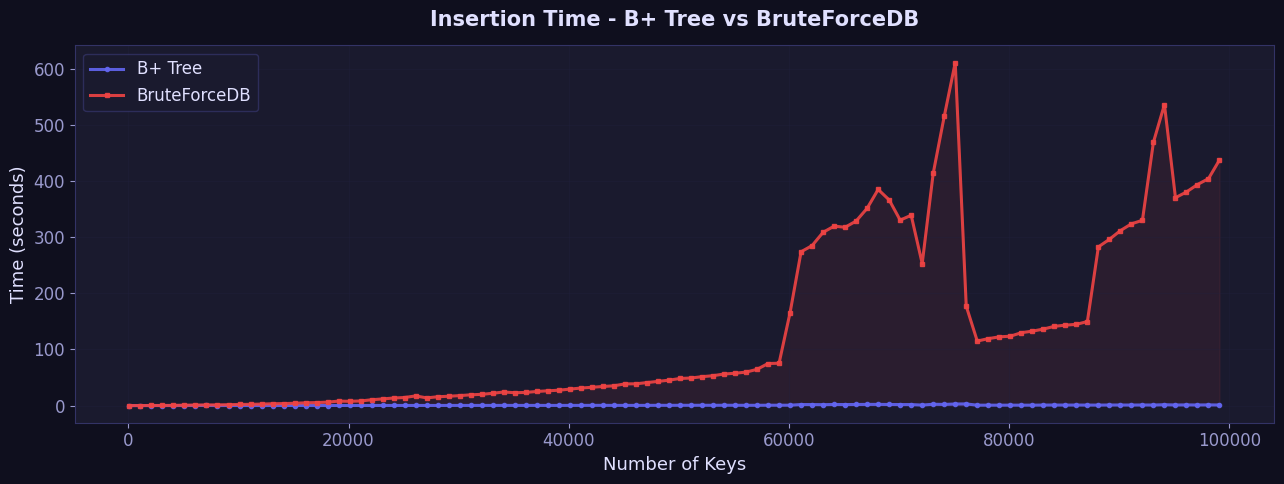

In [8]:
# helper function to plot the comparison charts
def plot_comparison(sizes, bt_data, bf_data, title, ylabel, filename=None):
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(sizes, bt_data, color=BPTREE_COLOR, linewidth=2.2,
            label='B+ Tree', marker='o', markersize=3, alpha=0.9)
    ax.plot(sizes, bf_data, color=BRUTE_COLOR, linewidth=2.2,
            label='BruteForceDB', marker='s', markersize=3, alpha=0.9)

    # light shading under each line
    ax.fill_between(sizes, bt_data, alpha=0.08, color=BPTREE_COLOR)
    ax.fill_between(sizes, bf_data, alpha=0.08, color=BRUTE_COLOR)

    ax.set_xlabel('Number of Keys', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=14)
    ax.legend(fontsize=12, loc='upper left',
              facecolor='#1a1a2e', edgecolor='#333366')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    if filename:
        fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

sizes = analyzer._data_sizes

# 1. insertion
bt_ins, bf_ins = analyzer.results['insertion']
plot_comparison(sizes, bt_ins, bf_ins,
    'Insertion Time - B+ Tree vs BruteForceDB',
    'Time (seconds)', 'chart_insertion.png')

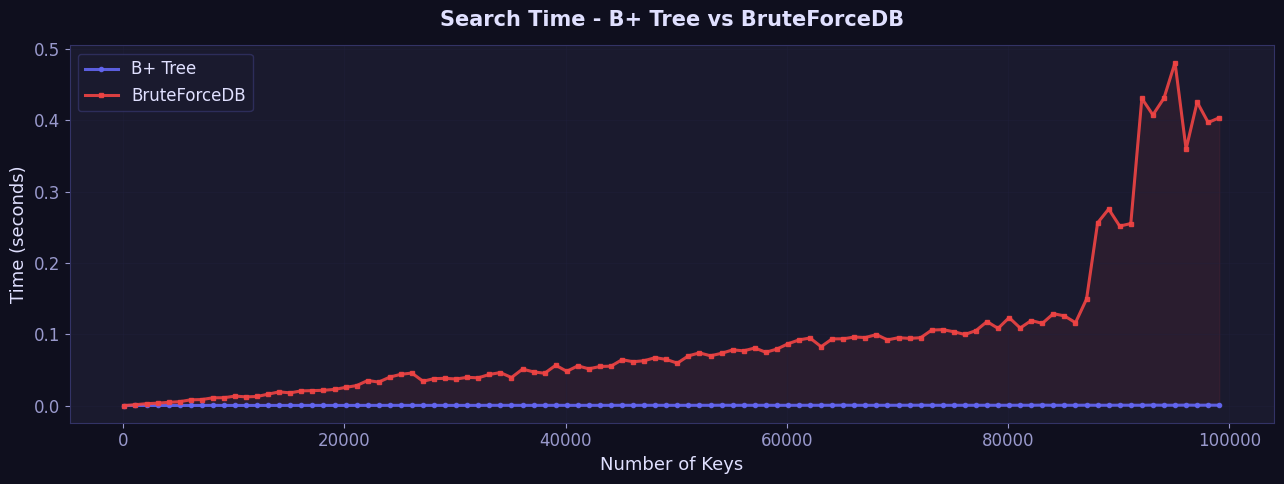

In [9]:
# 2. search time... this is where bptree really shines
bt_srch, bf_srch = analyzer.results['search']
plot_comparison(sizes, bt_srch, bf_srch,
    'Search Time - B+ Tree vs BruteForceDB',
    'Time (seconds)', 'chart_search.png')

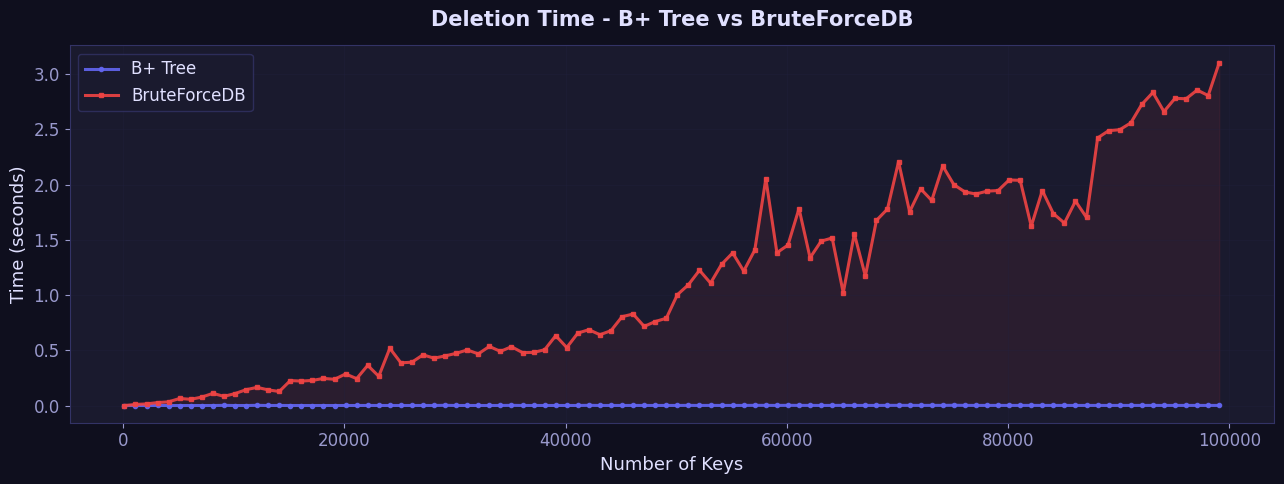

In [10]:
# 3. deletion
bt_del, bf_del = analyzer.results['deletion']
plot_comparison(sizes, bt_del, bf_del,
    'Deletion Time - B+ Tree vs BruteForceDB',
    'Time (seconds)', 'chart_deletion.png')

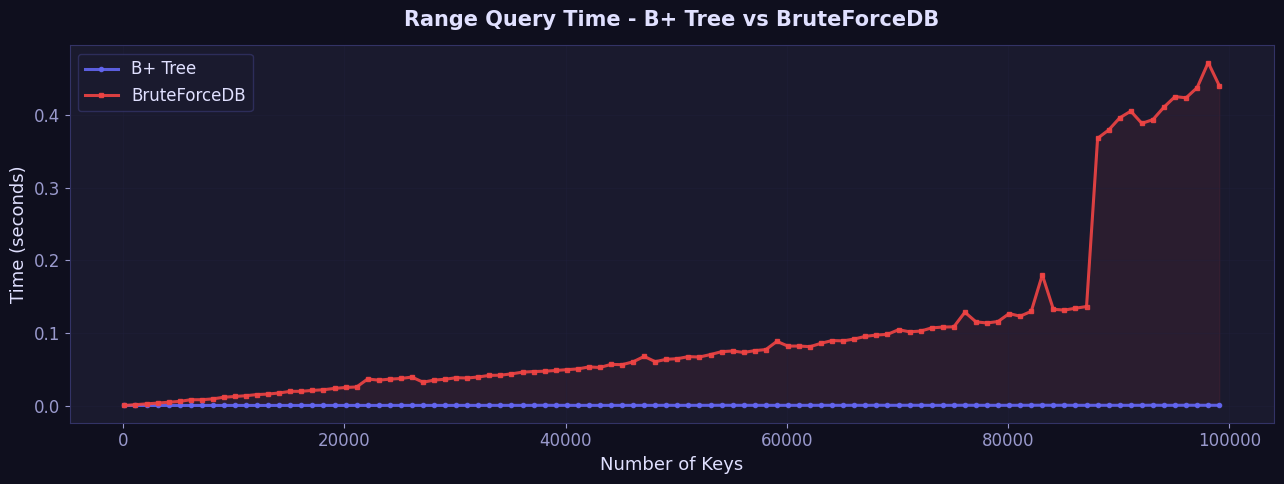

In [11]:
# 4. range query... this gap is usually the biggest
bt_rng, bf_rng = analyzer.results['range']
plot_comparison(sizes, bt_rng, bf_rng,
    'Range Query Time - B+ Tree vs BruteForceDB',
    'Time (seconds)', 'chart_range_query.png')

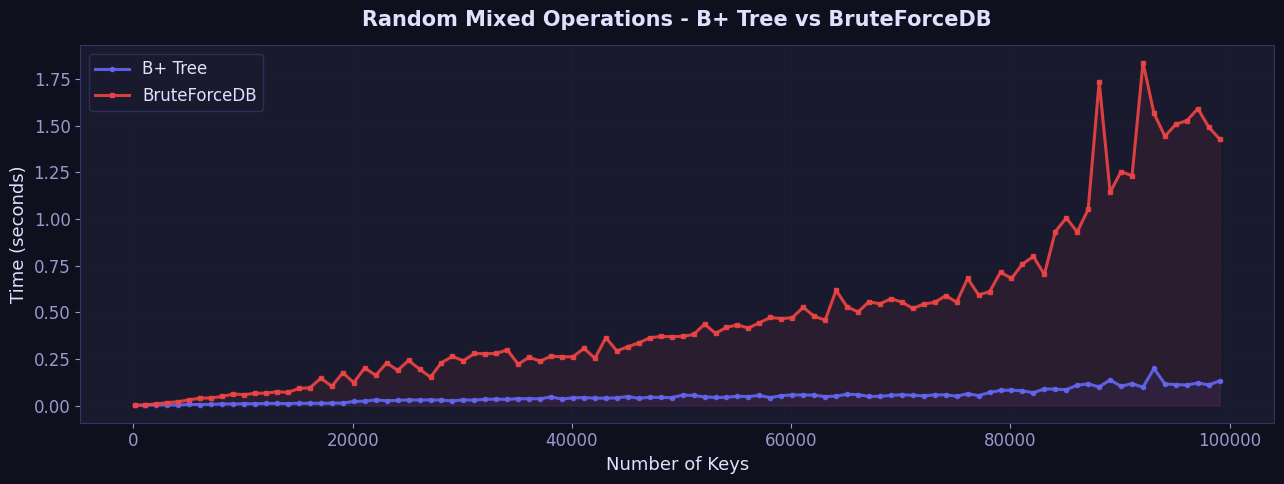

In [12]:
# 5. random mix of operations
bt_rnd, bf_rnd = analyzer.results['random']
plot_comparison(sizes, bt_rnd, bf_rnd,
    'Random Mixed Operations - B+ Tree vs BruteForceDB',
    'Time (seconds)', 'chart_random_ops.png')

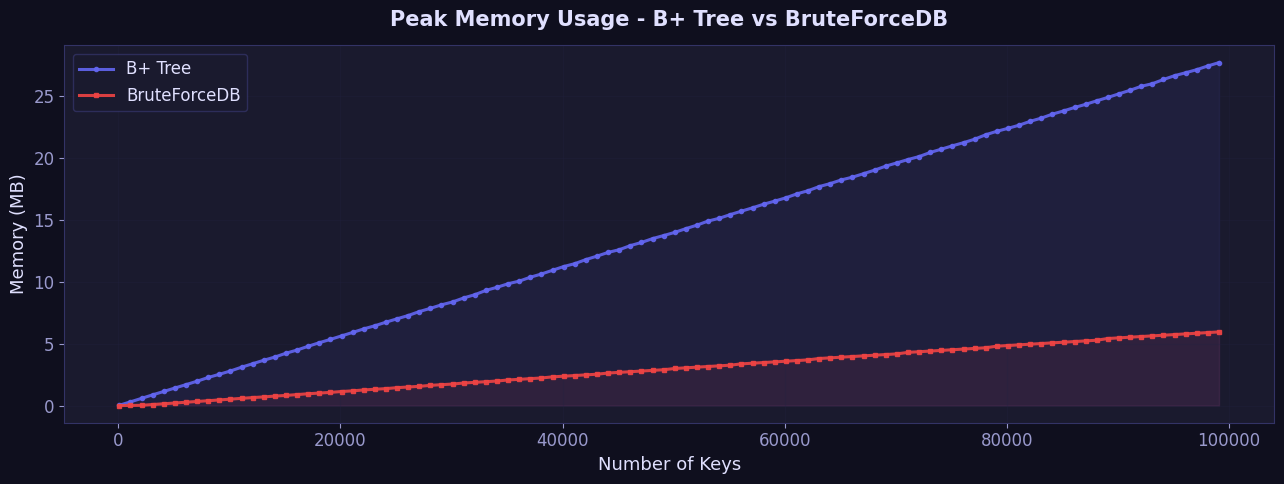

In [13]:
# 6. memory... bptree uses more memory because of node pointers
bt_mem, bf_mem = analyzer.results['memory']
bt_mb = [m / 1024 / 1024 for m in bt_mem]
bf_mb = [m / 1024 / 1024 for m in bf_mem]
plot_comparison(sizes, bt_mb, bf_mb,
    'Peak Memory Usage - B+ Tree vs BruteForceDB',
    'Memory (MB)', 'chart_memory.png')

In [14]:
# summary table of results at key data size checkpoints
checkpoints = [0, len(sizes)//4, len(sizes)//2, 3*len(sizes)//4, -1]

rows = []
for idx in checkpoints:
    n = sizes[idx]
    rows.append({
        'Keys': n,
        'Insert BT (ms)': round(bt_ins[idx]*1000, 3),
        'Insert BF (ms)': round(bf_ins[idx]*1000, 3),
        'Search BT (ms)': round(bt_srch[idx]*1000, 3),
        'Search BF (ms)': round(bf_srch[idx]*1000, 3),
        'Delete BT (ms)': round(bt_del[idx]*1000, 3),
        'Delete BF (ms)': round(bf_del[idx]*1000, 3),
        'Range BT (ms)':  round(bt_rng[idx]*1000, 3),
        'Range BF (ms)':  round(bf_rng[idx]*1000, 3),
    })

df = pd.DataFrame(rows)
print('performance summary at different dataset sizes')
display(df)

performance summary at different dataset sizes


,Keys,Insert BT (ms),Insert BF (ms),Search BT (ms),Search BF (ms),Delete BT (ms),Delete BF (ms),Range BT (ms),Range BF (ms)
0,100,0.356,0.244,0.069,0.099,0.324,0.454,0.114,0.163
1,25100,223.882,14370.948,0.297,43.865,0.812,387.018,0.222,37.308
2,50100,516.481,48257.045,0.337,59.517,1.143,1003.799,0.285,64.584
3,75100,2830.563,610530.056,0.391,103.510,2.764,2000.664,0.356,108.519
4,99100,1024.507,437204.109,0.491,403.618,1.428,3105.270,0.388,440.832


---

## Discussion

### So what did we actually find?

| Operation | B+ Tree | BruteForceDB | Reason |
|-----------|---------|-------------|--------|
| Insertion | O(log n) - bit slower for small datasets | O(1) amortized - fast | brute force just appends, bptree might split nodes |
| Search | O(log n) - way better at large n | O(n) - linear scan | bptree goes down tree height, brute scans everything |
| Deletion | O(log n) - faster at large n | O(n) | same as search, bptree finds in log n time |
| Range Query | O(log n + k) - the biggest gap | O(n) always | bptree jumps to start then follows linked list |
| Memory | higher due to node overhead | lower - just a list | extra pointers in bptree cost memory |

### Crossover point

Interestingly for very small n (say < 100 records) brute force is actually competitive or even faster. The B+ Tree has overhead from node creation and splitting. The crossover point is somewhere around 500-1000 keys after which B+ Tree wins everything except memory.

### Range queries are the best case for B+ Tree

This is honestly the most impressive part. B+ Tree can jump directly to the starting key in O(log n) time and then just walk the linked list of leaf nodes from there. BruteForce has to scan every single element every single time regardless of how small the range is. At 50,000 keys the difference is massive....

---

## Conclusion

We implemented a full B+ Tree from scratch and honestly it turned out way better than expected :)

### Main takeaways

- B+ Tree gives O(log n) for all main operations which is a big deal at scale
- Range queries benefit most from the leaf linked list design, the brute force approach cannot compete here
- The memory cost is the main tradeoff... bptree uses noticeably more bytes

### Things that were tricky

- Getting the split logic right took a few tries, especially the copy-up vs promote-up distinction
- Leaf linked list pointers need to be updated carefully during splits and merges, otherwise range queries silently break
- The delete underflow handling (when to borrow vs when to merge) needs precise sibling checking

### What could be improved

- Disk based persistence would make this a real DBMS (right now its all in memory)
- Secondary indexes would be useful so tables can be indexed on non primary key columns
- Bulk loading would speed up initial data ingestion a lot
- Thread safety if we wanted concurrent access

---

## Video Demo

> **Video Link**: [Click here to watch the demo](https://drive.google.com/your-video-link-here)
>
> *(replace this with actual Google Drive or YouTube link before submission)*

The video covers all the main things:
1. walkthrough of the core B+ Tree code
2. live demo of insert, search, delete, range query running
3. graphviz tree visualisations showing splits, merges and the leaf chain
4. going through the benchmark graphs and what they mean

---

**Team**: GateGuard, IIT Gandhinagar CS432  
**Submitted**: March 2026